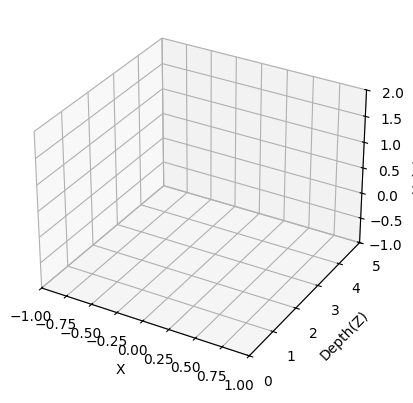

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

frames = []
with open('sample.skeleton', 'r') as f:
    lines = f.readlines()

idx = 0
while idx < len(lines):
    if lines[idx].strip() == '25':  # 관절 데이터 시작점 찾기
        # 다음 25줄에서 X, Y, Z 좌표만 float으로 추출
        joints = [list(map(float, lines[i].split()[:3])) for i in range(idx+1, idx+26)]
        frames.append(np.array(joints))
        idx += 26
    else:
        idx += 1

# 2. 뼈대 연결 정보 (NTU RGB+D 기준 25개 관절)
bones = [(0,1), (1,20), (20,2), (2,3), (20,4), (4,5), (5,6), (6,7), (7,21), (7,22), 
         (20,8), (8,9), (9,10), (10,11), (11,23), (11,24), (0,12), (12,13), (13,14), 
         (14,15), (0,16), (16,17), (17,18), (18,19)]

# 3. 3D 애니메이션 세팅
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set(xlim=(-1, 1), ylim=(0, 5), zlim=(-1, 2), xlabel='X', ylabel='Depth(Z)', zlabel='Height(Y)')

lines_3d = [ax.plot([], [], [], 'b-')[0] for _ in bones]
scatter = ax.scatter([], [], [], c='r')

def update(frame):
    pts = frames[frame]
    # 3D 뷰포트 방향에 맞게 X, Z, Y 순서로 매핑
    scatter._offsets3d = (pts[:,0], pts[:,2], pts[:,1])
    for line, (j1, j2) in zip(lines_3d, bones):
        line.set_data_3d([pts[j1,0], pts[j2,0]], [pts[j1,2], pts[j2,2]], [pts[j1,1], pts[j2,1]])
    return lines_3d + [scatter]

ani = FuncAnimation(fig, update, frames=len(frames), interval=30, blit=False)
plt.show()